## Eurostsat electricity prices Half-Yearly dataset, aggregated

Aggregated meaning i summed up the half years:)

##### Quelle: https://ec.europa.eu/eurostat/databrowser/view/nrg_pc_205__custom_16541313/default/table?lang=en
##### Bookmark: https://ec.europa.eu/eurostat/databrowser/bookmark/d3c6c0b9-4653-48f5-a522-2aea84b5ee38?lang=en


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import os

# Define input/output paths
EUROSTAT_BIANNUAL_FILE = "in/prices/estat_nrg_pc_205_filtered_en.csv"
PLOT_OUT_DIR_ANNUAL = "out/price/eurostat_annual"
EXCEL_OUTPUT_ANNUAL = "out/price/eurostat_electricity_prices_annual.xlsx"

# Ensure output directories exist
os.makedirs(PLOT_OUT_DIR_ANNUAL, exist_ok=True)


c:\Users\sulta\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
df_biannual_raw = pd.read_csv(EUROSTAT_BIANNUAL_FILE, delimiter=",", encoding="utf-8")

DF_PRICES = df_biannual_raw[[
    "TIME_PERIOD",
    "tax",  # z. B. I_TAX oder X_TAX
    "Taxes",  # Beschreibung
    "OBS_VALUE"
]].copy()
# 
DF_PRICES["OBS_VALUE"] = pd.to_numeric(DF_PRICES["OBS_VALUE"], errors="coerce")
# DF_PRICES = DF_PRICES.dropna(subset=["OBS_VALUE"])

# Select only "All taxex and levies included"
DF_PRICES = DF_PRICES[
    DF_PRICES["tax"] == "I_TAX"
]

# Extract year part from 'TIME_PERIOD'
DF_PRICES["year"] = DF_PRICES["TIME_PERIOD"].str.extract(r"^(\d{4})").astype(int)

# Group by year and take the mean of OBS_VALUE
DF_PRICES = (
    DF_PRICES
    .groupby("year", as_index=False)["OBS_VALUE"]
    .mean()
)

# Rename cols
DF_PRICES = DF_PRICES.rename(
    columns={
    "OBS_VALUE": "price"
    }
)
DF_PRICES


,year,price
0,2007,0.10580
1,2008,0.11935
2,2009,0.12330
3,2010,0.12450
4,2011,0.14290
5,2012,0.14265
6,2013,0.15170
7,2014,0.15365
8,2015,0.15125
9,2016,0.13645


In [3]:
# Vorbereitung
df_prophet = DF_PRICES.copy()
df_prophet["ds"] = pd.to_datetime(df_prophet["year"].astype(str) + "-01-01")
df_prophet["y"] = df_prophet["price"]

# Prophet-Modell fitten
model = Prophet(yearly_seasonality=True)
model.fit(df_prophet[["ds", "y"]])

# Forecast-Zeitraum: bis 2050
future_years = pd.date_range(start="2025-01-01", end="2050-01-01", freq="YS")
future_df = pd.DataFrame({"ds": future_years})

# Prognose durchführen
forecast = model.predict(future_df)
DF_FORECAST = forecast[["ds", "yhat"]].copy()
DF_FORECAST["year"] = DF_FORECAST["ds"].dt.year
DF_FORECAST.rename(columns={"yhat": "price"}, inplace=True)

DF_FORECAST

14:29:48 - cmdstanpy - INFO - Chain [1] start processing
14:29:48 - cmdstanpy - INFO - Chain [1] done processing


,ds,price,year
0,2025-01-01,0.202951,2025
1,2026-01-01,0.211227,2026
2,2027-01-01,0.218364,2027
3,2028-01-01,0.224362,2028
4,2029-01-01,0.225257,2029
5,2030-01-01,0.233533,2030
6,2031-01-01,0.240671,2031
7,2032-01-01,0.246669,2032
8,2033-01-01,0.247564,2033
9,2034-01-01,0.255840,2034


In [4]:
# Vereinheitlichung der Spaltennamen für den Merge
df_hist = DF_PRICES[["year", "price"]].copy()
# df_hist.rename(columns={"cost": "price"}, inplace=True)
df_hist["type"] = "Historical"

df_forecast = DF_FORECAST[["year", "price"]].copy()
df_forecast["type"] = "Predicted"

# Kombinieren von historischen und prognostizierten Daten
DF_COMBINED = pd.concat([df_hist, df_forecast], ignore_index=True).sort_values("year").reset_index(drop=True)

DF_COMBINED


,year,price,type
0,2007,0.105800,Historical
1,2008,0.119350,Historical
2,2009,0.123300,Historical
3,2010,0.124500,Historical
4,2011,0.142900,Historical
5,2012,0.142650,Historical
6,2013,0.151700,Historical
7,2014,0.153650,Historical
8,2015,0.151250,Historical
9,2016,0.136450,Historical


In [5]:
with pd.ExcelWriter(EXCEL_OUTPUT_ANNUAL, engine="xlsxwriter") as writer:
    DF_COMBINED.to_excel(writer, sheet_name="Prices", index=False)

    workbook = writer.book
    worksheet = writer.sheets["Prices"]

    # Spaltenbreiten & Formate
    header_format = workbook.add_format({'bold': True, 'bg_color': '#D9D9D9'})
    price_format = workbook.add_format({'num_format': '0.00000 "€"', 'align': 'right'})

    worksheet.set_row(0, 18, header_format)
    worksheet.set_column(0, 0, 10)             # year
    worksheet.set_column(1, 1, 14, price_format)  # price
    worksheet.set_column(2, 2, 12)             # type


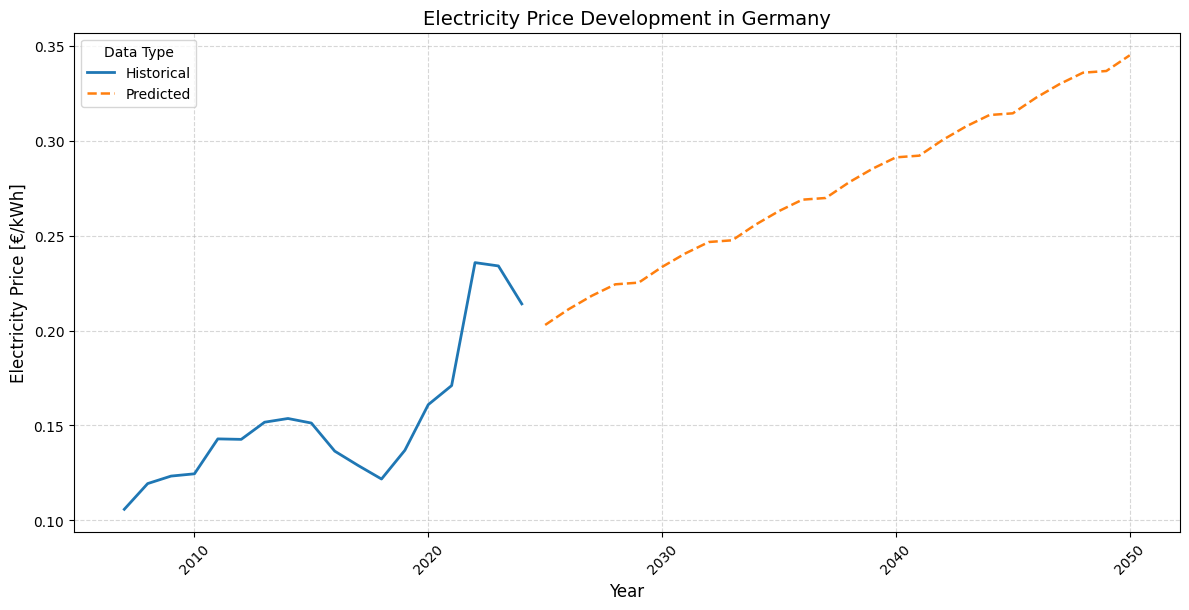

<Figure size 640x480 with 0 Axes>

In [6]:
plt.figure(figsize=(12, 6))

# Plot lines by type
for label, group in DF_COMBINED.groupby("type"):
    plt.plot(group["year"], group["price"], label=label, linewidth=2 if label == "Historical" else 1.8, linestyle="-" if label == "Historical" else "--")

# Labels and style
plt.title("Electricity Price Development in Germany", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Electricity Price [€/kWh]", fontsize=12)
plt.legend(title="Data Type")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=45)

plt.show()

plt.savefig(os.path.join(PLOT_OUT_DIR_ANNUAL,"electricity_price_development.png"), dpi=300, bbox_inches="tight")

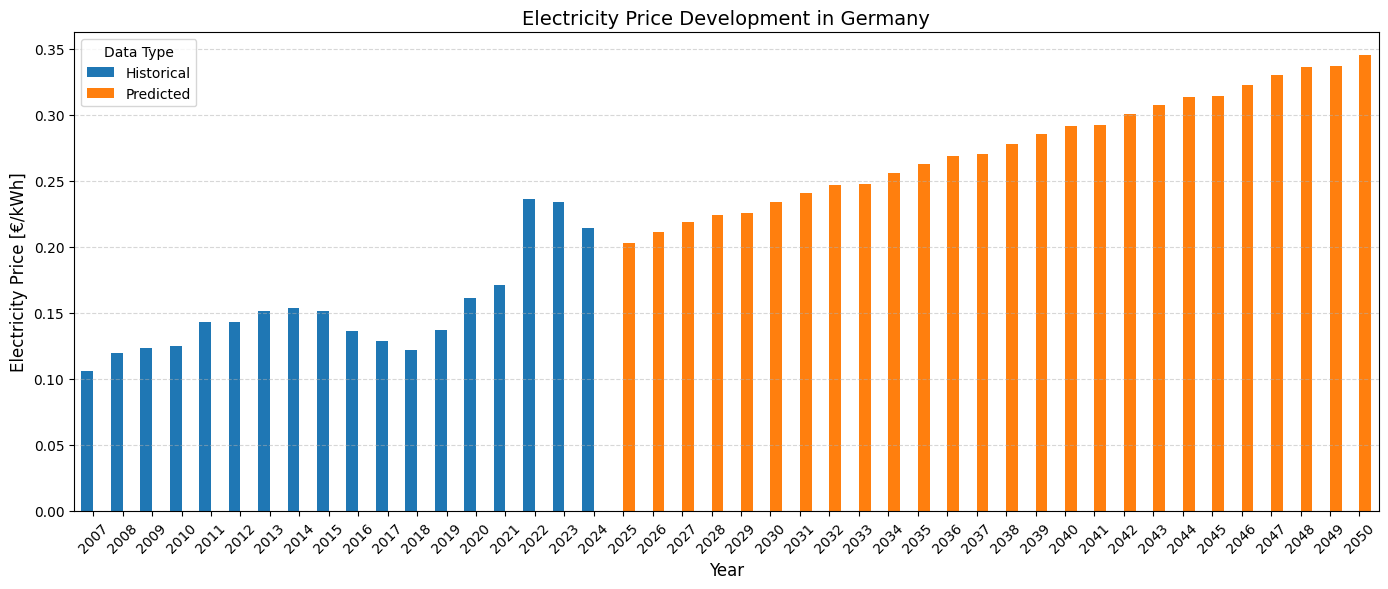

<Figure size 640x480 with 0 Axes>

In [7]:

# Prepare data for grouped bar chart
pivot_prices = DF_COMBINED.pivot(index="year", columns="type", values="price")
pivot_prices = pivot_prices.sort_index()

# Plot
ax = pivot_prices.plot(kind="bar", figsize=(14, 6), width=0.8)

plt.title("Electricity Price Development in Germany", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Electricity Price [€/kWh]", fontsize=12)
plt.legend(title="Data Type")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

plt.savefig(os.path.join(PLOT_OUT_DIR_ANNUAL,"electricity_price_development_barchart.png"), dpi=300, bbox_inches="tight")
